# Modelos de Séries Temporais

### Secao 3.4: Modelo ARIMA

Este notebook reproduz, em Python, a rotina em R para modelagem ETS aplicada a dados de consumo de energia.

In [ ]:
##############################################################
#          Unidade 3: Modelos de series temporais            #
#                   Secao 3.4: Modelo ARIMA                  # 
##############################################################

In [1]:
# 📦 Importando pacotes necessários
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from statsmodels.tsa.api import ExponentialSmoothing
from statsmodels.tsa.stattools import adfuller, acf, pacf
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

from statsmodels.tsa.arima.model import ARIMA
from statsmodels.stats.diagnostic import acorr_ljungbox
from scipy.stats import kstest, norm

import pmdarima as pm

In [2]:
##############################################################
# 📊 Carregando os dados
# (equivalente ao load("populacao.RData"))
##############################################################

popul = pd.read_csv("populacao.csv",
                 index_col=0,          # primeira coluna vira índice
                parse_dates=True)      # converte automaticamente para datetime

# Supondo que a coluna relevante seja a segunda (como no R)
#popul = df.iloc[:,1]

# Criando série temporal com índice de anos
# anos = pd.period_range(start="1990", end="2022", freq="Y") # de 1990 até 2022
# popul = pd.Series(popul.values, index=anos).index.to_timestamp()
# opcional (mas importante para ETS)
popul.index = pd.DatetimeIndex(popul.index, freq="YS")


In [3]:
popul.head()

,populacao
Data,
1990-01-01,73295785
1991-01-01,74340353
1992-01-01,75305624
1993-01-01,76250143
1994-01-01,77237944


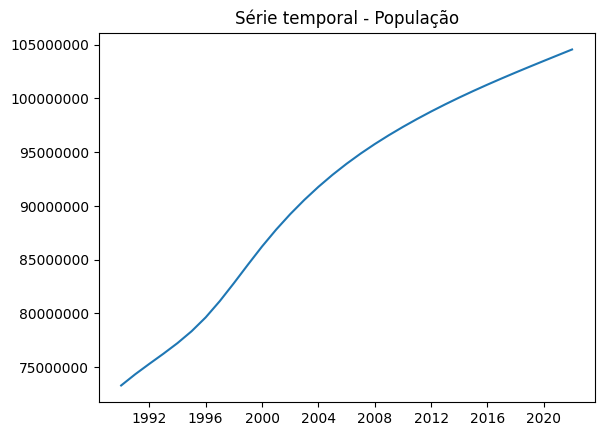

In [4]:
##############################################################
# 📈 Plotando a série temporal
##############################################################

plt.plot(popul)
plt.ticklabel_format(style='plain', axis='y')
plt.title("Série temporal - População")
plt.show()

In [ ]:
##############################################################
# ⚠️ Teste de sazonalidade não aplicável (dados anuais)
##############################################################

# Em Python, não há equivalente direto ao combined_test
# e também não faz sentido para frequência anual.

In [5]:
##############################################################
# 🔍 Modelo ETS
##############################################################

modelo_ets = ExponentialSmoothing(popul, trend='add', seasonal=None)
fit_ets = modelo_ets.fit()

print(fit_ets.summary())

# ✔️ Interpretação:
# Tendência aditiva e ausência de sazonalidade

                       ExponentialSmoothing Model Results                       
Dep. Variable:                populacao   No. Observations:                   33
Model:             ExponentialSmoothing   SSE                   247797814844.000
Optimized:                         True   AIC                            758.399
Trend:                         Additive   BIC                            764.385
Seasonal:                          None   AICC                           761.630
Seasonal Periods:                  None   Date:                 Sat, 11 Apr 2026
Box-Cox:                          False   Time:                         13:47:48
Box-Cox Coeff.:                    None                                         
                       coeff                 code              optimized      
------------------------------------------------------------------------------
smoothing_level            1.0000000                alpha                 True
smoothing_trend            1.00000

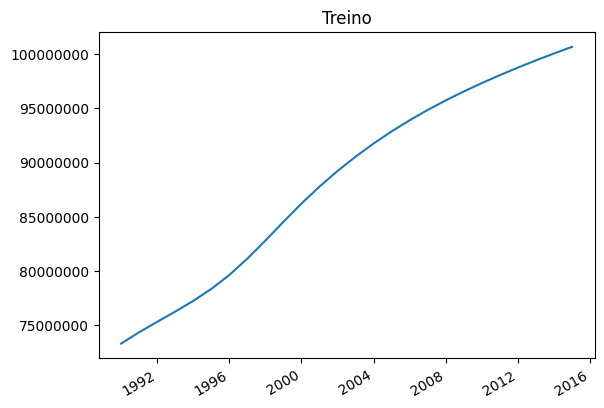

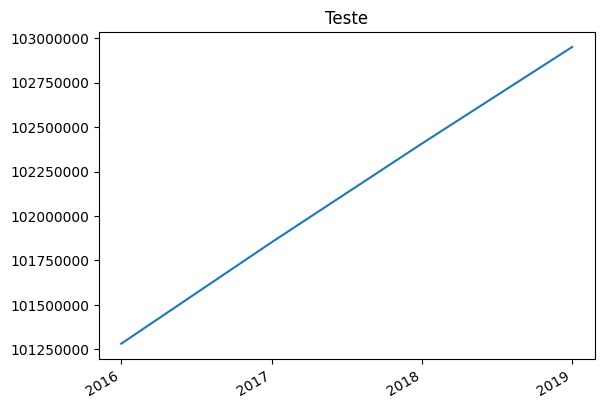

Tamanho treino: 26
Tamanho teste: 4


In [19]:
##############################################################
# ✂️ Divisão treino e teste
##############################################################
import matplotlib.dates as mdates

treino = popul.loc["1990":"2015"]
teste = popul.loc["2016":"2019"]

# --- Treino ---
fig, ax = plt.subplots()
ax.plot(treino)

ax.xaxis.set_major_locator(mdates.YearLocator(4))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

ax.ticklabel_format(style='plain', axis='y')
ax.set_title("Treino")

fig.autofmt_xdate()
plt.show()

# --- Teste ---
fig, ax = plt.subplots()
ax.plot(teste)

ax.xaxis.set_major_locator(mdates.YearLocator(1))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

ax.ticklabel_format(style='plain', axis='y')
ax.set_title("Teste")

fig.autofmt_xdate()
plt.show()

print("Tamanho treino:", len(treino))
print("Tamanho teste:", len(teste))

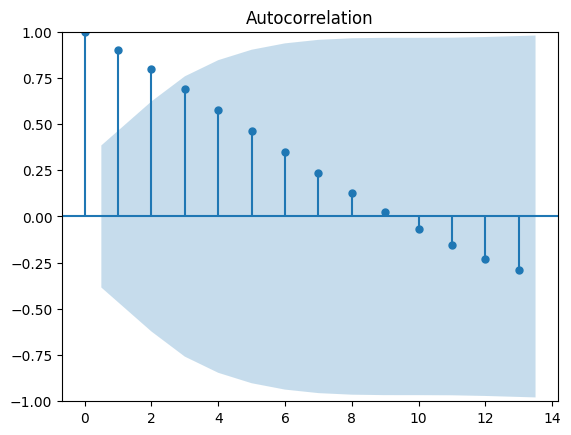

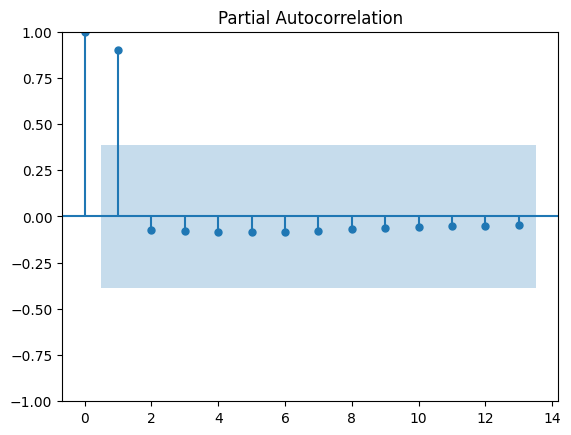

In [20]:
##############################################################
# 📉 ACF e PACF
##############################################################

plot_acf(treino)
plt.show()

plot_pacf(treino)
plt.show()

# ✔️ Indícios de modelo AR ou ARMA

In [21]:
##############################################################
# 🔁 Número de diferenciações (equivalente ao ndiffs)
##############################################################

ndiffs = pm.arima.ndiffs(treino, test='adf')
print("Número de diferenças necessárias:", ndiffs)

Número de diferenças necessárias: 2


In [53]:
##############################################################
# 🤖 AUTO ARIMA
##############################################################

modelo_auto = pm.auto_arima(
    treino,
    start_p=0, max_p=3,
    start_q=0, max_q=3,
    start_d=0, max_d=3, # resultado de ndiffs acima
    seasonal=False,
    information_criterion='aicc',   # 🔥 igual ao R
    with_intercept=True,           # 🔥 equivalente a muitos casos do R com d=2
    stepwise=True,                  # 🔥 igual ao comportamento padrão do R
    trace=True,
    suppress_warnings=True,
    error_action='ignore'
)

#print(modelo_auto.summary())

# ✔️ Esperado: ARIMA(2,2,0)

Performing stepwise search to minimize aicc
 ARIMA(0,1,0)(0,0,0)[0] intercept   : AICC=712.564, Time=0.02 sec
 ARIMA(1,1,0)(0,0,0)[0] intercept   : AICC=4048.164, Time=0.02 sec
 ARIMA(0,1,1)(0,0,0)[0] intercept   : AICC=715.441, Time=0.01 sec
 ARIMA(0,1,0)(0,0,0)[0]             : AICC=770.807, Time=0.01 sec
 ARIMA(1,1,1)(0,0,0)[0] intercept   : AICC=inf, Time=0.15 sec

Best model:  ARIMA(0,1,0)(0,0,0)[0] intercept
Total fit time: 0.212 seconds


In [23]:
##############################################################
# 📊 Teste Dickey-Fuller
##############################################################

resultado_adf = adfuller(treino)

print("ADF Statistic:", resultado_adf[0])
print("p-value:", resultado_adf[1])

# ✔️ Se p-value > 0.05 → série não estacionária

ADF Statistic: -2.2148353411134116
p-value: 0.20090521106910392


In [ ]:
##############################################################
# 🔮 Previsão
##############################################################

modelo_arima = ARIMA(treino, order=modelo_auto.order)
fit_arima = modelo_arima.fit()

forecast = fit_arima.get_forecast(steps=4)
mean_forecast = forecast.predicted_mean
conf_int = forecast.conf_int()

print(mean_forecast)

2016-01-01    101303234.0
2017-01-01    101913812.0
2018-01-01    102524390.0
2019-01-01    103134968.0
Freq: YS-JAN, Name: predicted_mean, dtype: float64


In [67]:
fit_arima.resid

Data
1990-01-01    7.329578e+07
1991-01-01   -7.224299e+07
1992-01-01   -7.929700e+04
1993-01-01   -2.075200e+04
1994-01-01    4.328200e+04
1995-01-01    1.149050e+05
1996-01-01    1.839420e+05
1997-01-01    2.296420e+05
1998-01-01    1.514670e+05
1999-01-01    5.790100e+04
2000-01-01   -3.950600e+04
2001-01-01   -1.149390e+05
2002-01-01   -1.316080e+05
2003-01-01   -1.173760e+05
2004-01-01   -1.076220e+05
2005-01-01   -9.493200e+04
2006-01-01   -9.127300e+04
2007-01-01   -7.833000e+04
2008-01-01   -6.857500e+04
2009-01-01   -5.663600e+04
2010-01-01   -5.136800e+04
2011-01-01   -4.033100e+04
2012-01-01   -3.582200e+04
2013-01-01   -3.057900e+04
2014-01-01   -3.075500e+04
2015-01-01   -2.542800e+04
Freq: YS-JAN, dtype: float64

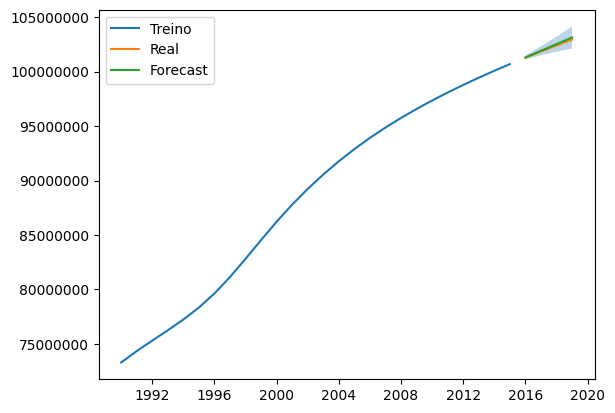

In [63]:
##############################################################
# 📊 Plot previsão
##############################################################

plt.plot(treino, label="Treino")
plt.plot(teste, label="Real")
plt.plot(mean_forecast, label="Forecast")

plt.fill_between(
    mean_forecast.index,
    conf_int.iloc[:, 0],
    conf_int.iloc[:, 1],
    alpha=0.3
)

plt.ticklabel_format(style='plain', axis='y')
plt.legend()
plt.show()

In [65]:
##############################################################
# 📏 Acurácia
##############################################################

from sklearn.metrics import mean_absolute_error, mean_squared_error

mae = mean_absolute_error(teste, mean_forecast)
rmse = np.sqrt(mean_squared_error(teste, mean_forecast))

print("MAE:", mae)
print("RMSE:", rmse)

MAE: 95730.75
RMSE: 113424.77958651716


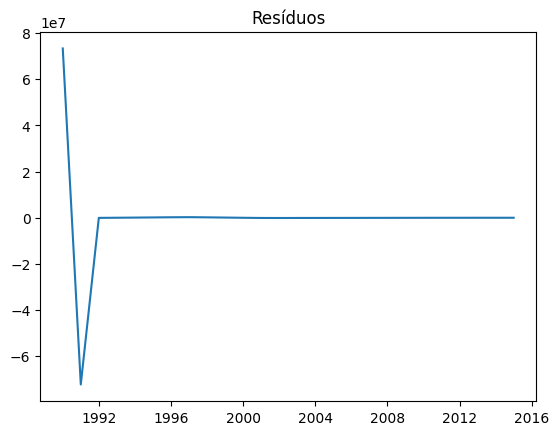

In [72]:
##############################################################
# 🔍 Diagnóstico dos resíduos
##############################################################

residuos = fit_arima.resid

plt.plot(residuos)
# plt.ticklabel_format(style='plain', axis='y')
plt.title("Resíduos")
plt.show()

In [42]:
##############################################################
# 1️⃣ Teste Ljung-Box (autocorrelação)
##############################################################

ljung_box = acorr_ljungbox(residuos, lags=[10], return_df=True)
print(ljung_box)

# ✔️ p-value > 0.05 → resíduos independentes

     lb_stat  lb_pvalue
10  7.257225   0.700959


In [43]:
##############################################################
# 2️⃣ Teste de normalidade (Kolmogorov-Smirnov)
##############################################################

ks_stat, ks_p = kstest(
    residuos,
    'norm',
    args=(np.mean(residuos), np.std(residuos))
)

print("KS p-value:", ks_p)

# ✔️ p-value > 0.05 → normalidade

KS p-value: 1.615393029797671e-05


In [44]:
##############################################################
# 3️⃣ Teste ARCH (heterocedasticidade)
##############################################################

from statsmodels.stats.diagnostic import het_arch

arch_test = het_arch(residuos)
print("ARCH p-value:", arch_test[1])

# ✔️ p-value > 0.05 → sem efeito ARCH/GARCH

##############################################################
# ✔️ Conclusão:
# Modelo ARIMA adequado, resíduos bem comportados
##############################################################

ARCH p-value: 0.009720910117146596
